# Olist Brazilian E-Commerce Data Preparation
This notebook loads the 9 CSV files from the Olist E-commerce dataset, performs left joins to create a master dataframe centered around `order_items`, handles specific missing values, and converts timestamps to datetime.

In [1]:
import pandas as pd
import os

data_dir = './data' # Change this path to where your dataset actually resides

### 1. Load all 9 CSV files

In [2]:
customers = pd.read_csv(os.path.join(data_dir, 'olist_customers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(data_dir, 'olist_geolocation_dataset.csv'))
order_items = pd.read_csv(os.path.join(data_dir, 'olist_order_items_dataset.csv'))
order_payments = pd.read_csv(os.path.join(data_dir, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(data_dir, 'olist_order_reviews_dataset.csv'))
orders = pd.read_csv(os.path.join(data_dir, 'olist_orders_dataset.csv'))
products = pd.read_csv(os.path.join(data_dir, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(data_dir, 'olist_sellers_dataset.csv'))
category_translation = pd.read_csv(os.path.join(data_dir, 'product_category_name_translation.csv'))

### 2. Convert timestamp columns to datetime objects

In [3]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

for col in ['review_creation_date', 'review_answer_timestamp']:
    order_reviews[col] = pd.to_datetime(order_reviews[col])
    
for col in ['order_purchase_timestamp', 'order_approved_at', 
           'order_delivered_carrier_date', 'order_delivered_customer_date', 
           'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

### 3. Create a master dataframe centered around 'order_items'
We use left joins to carefully attach required fields keeping `order_items` as our base.

In [4]:
master_df = order_items.merge(orders, on='order_id', how='left')
master_df = master_df.merge(products, on='product_id', how='left')
master_df = master_df.merge(sellers, on='seller_id', how='left')
master_df = master_df.merge(order_payments, on='order_id', how='left')
master_df = master_df.merge(order_reviews, on='order_id', how='left')
master_df = master_df.merge(customers, on='customer_id', how='left')
master_df = master_df.merge(category_translation, on='product_category_name', how='left')

**Geolocation Join Strategy**  
Handling geolocation requires careful merging to avoid exploding row counts, as there are many coordinates per zip code prefix. We group them to unique prefix coordinates.

In [5]:
geo_grouped = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# Join Customer Location
master_df = master_df.merge(geo_grouped, 
                            left_on='customer_zip_code_prefix', 
                            right_on='geolocation_zip_code_prefix', 
                            how='left')
master_df.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}, inplace=True)
master_df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

# Join Seller Location
master_df = master_df.merge(geo_grouped, 
                            left_on='seller_zip_code_prefix', 
                            right_on='geolocation_zip_code_prefix', 
                            how='left')
master_df.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}, inplace=True)
master_df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

### 4. Handle Missing Values

In [6]:
# Missing product_category_name
master_df['product_category_name'] = master_df['product_category_name'].fillna('Unknown')
master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('Unknown')

# Missing review_score: Filling with Median
median_score = master_df['review_score'].median()
master_df['review_score'] = master_df['review_score'].fillna(median_score)

print(f"Master DataFrame shape: {master_df.shape}")
master_df.head()

Master DataFrame shape: (118310, 44)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-22 10:57:03,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,-21.762775,-41.309633,-22.496953,-44.127492
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15 11:34:13,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,-20.220527,-50.903424,-23.565096,-46.518565
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-23 16:06:31,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,furniture_decor,-19.870305,-44.593326,-22.262584,-46.171124
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-15 16:39:01,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumery,-23.089925,-46.611654,-20.553624,-47.387359
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-03 10:54:59,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,garden_tools,-23.243402,-46.827614,-22.929384,-53.135873


### 5. Cost Leadership Analysis
We analyze the core categories to understand price positioning by calculating the `Price_Competitiveness_Index`.

Top 10 Categories: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'furniture_decor', 'computers_accessories', 'housewares', 'watches_gifts', 'telephony', 'garden_tools', 'auto']

Average Price & Freight Value for Top 10 Categories:
  product_category_name_english   avg_price  avg_freight_value
0                          auto  140.544432          21.826466
1                bed_bath_table   92.363121          18.386130
2         computers_accessories  116.571005          18.933539
3               furniture_decor   87.420309          20.750798
4                  garden_tools  113.175017          23.074941
5                 health_beauty  129.779503          18.884548
6                    housewares   90.634274          20.967827
7                sports_leisure  114.349609          19.501774
8                     telephony   71.851678          15.721741
9                 watches_gifts  201.886842          16.823216


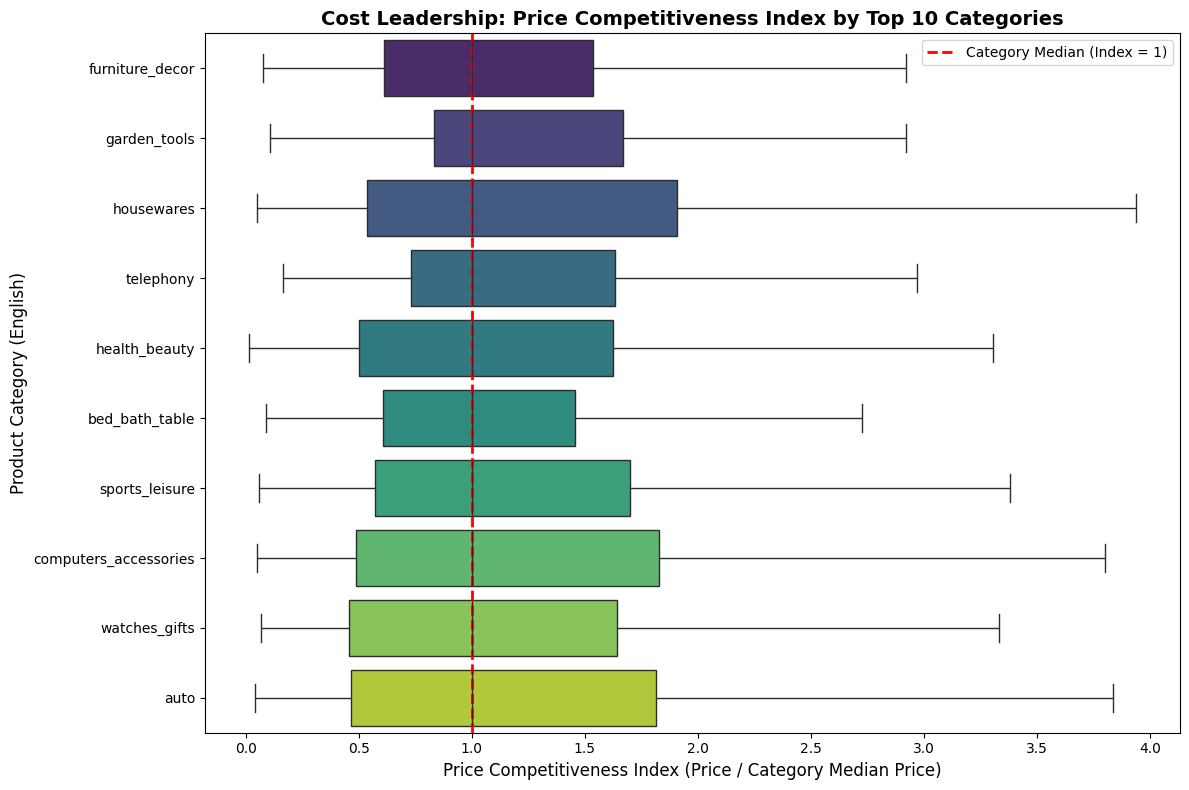

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the Top 10 product categories by volume
top_10_categories = master_df['product_category_name_english'].value_counts().nlargest(10).index
print(f"Top 10 Categories: {list(top_10_categories)}\n")

cost_leadership_df = master_df[master_df['product_category_name_english'].isin(top_10_categories)].copy()

# 2. Calculate average price and average freight value
category_stats = cost_leadership_df.groupby('product_category_name_english')[['price', 'freight_value']].mean().reset_index()
category_stats.rename(columns={'price': 'avg_price', 'freight_value': 'avg_freight_value'}, inplace=True)
print("Average Price & Freight Value for Top 10 Categories:")
print(category_stats)

# 3. Create Price_Competitiveness_Index
# First calculate median price per category
category_medians = cost_leadership_df.groupby('product_category_name_english')['price'].median().reset_index()
category_medians.rename(columns={'price': 'category_median_price'}, inplace=True)

# Merge medians back onto our df
cost_leadership_df = cost_leadership_df.merge(category_medians, on='product_category_name_english', how='left')

# Calculate Price_Competitiveness_Index (Product Price / Category Median Price)
cost_leadership_df['Price_Competitiveness_Index'] = cost_leadership_df['price'] / cost_leadership_df['category_median_price']

# 4. Visualize the index using a Seaborn Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=cost_leadership_df, 
    y='product_category_name_english', 
    x='Price_Competitiveness_Index', 
    hue='product_category_name_english',
    palette='viridis',
    orient='h',
    showfliers=False # Hide extreme outliers to better visualize the competitive spread
)

plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Category Median (Index = 1)')
plt.title('Cost Leadership: Price Competitiveness Index by Top 10 Categories', fontsize=14, fontweight='bold')
plt.ylabel('Product Category (English)', fontsize=12)
plt.xlabel('Price Competitiveness Index (Price / Category Median Price)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


### 6. Differentiation Advantage Analysis
This section explores delivery speed and identifies "Premium" sellers who maintain high operational and review standards despite above-average pricing.

In [8]:
import numpy as np

# 1. Calculate Delivery_Speed (in days)
master_df['Delivery_Speed_Days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Drop NaN values for these specific columns to ensure clean correlation
delivered_orders = master_df.dropna(subset=['Delivery_Speed_Days', 'review_score']).copy()

# 2. Calculate the correlation between 'Delivery_Speed' and 'review_score'
correlation = delivered_orders['Delivery_Speed_Days'].corr(delivered_orders['review_score'])
print(f"Correlation between Delivery Speed (Days) and Review Score: {correlation:.4f}")
print("Note: A negative correlation implies that as delivery time increases, the review score tends to decrease.\n")

# 3. Identify Top 5 Sellers: High Ratings despite Above-Average Prices
# Require a minimum of 10 order items to eliminate outliers with a single lucky 5-star review
order_counts = delivered_orders['seller_id'].value_counts()
valid_sellers = order_counts[order_counts >= 10].index 

seller_metrics = delivered_orders[delivered_orders['seller_id'].isin(valid_sellers)].groupby('seller_id').agg(
    avg_price=('price', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Calculate the overall average seller price
global_avg_price = seller_metrics['avg_price'].mean()
print(f"Global Average Seller Price: ${global_avg_price:.2f}\n")

# Filter for Premium sellers (price higher than average)
premium_sellers = seller_metrics[seller_metrics['avg_price'] > global_avg_price].copy()

# Sort by highest review score, then by volume (total_orders)
top_premium_sellers = premium_sellers.sort_values(by=['avg_review_score', 'total_orders'], ascending=[False, False])

print("--- Top 5 Sellers With Premium Brand Advantage ---")
top_premium_sellers.head()


Correlation between Delivery Speed (Days) and Review Score: -0.2954
Note: A negative correlation implies that as delivery time increases, the review score tends to decrease.

Global Average Seller Price: $144.46

--- Top 5 Sellers With Premium Brand Advantage ---


,seller_id,avg_price,avg_review_score,total_orders
241,2addf05f476d0637864454e93ba673d5,379.333333,5.000000,12
449,53b0300ca793f9834cd69c0678d35ee8,166.215000,5.000000,5
1033,c394e193cda3b4225ff2094d32184849,284.990000,5.000000,2
936,b1fecf4da1fa2689bccffa0121953643,183.954667,4.966667,19
506,5c030029b5916fed0986310385ec9009,402.127273,4.909091,7


### 7. Competitive Advantage Scoreboard
Bringing it all together: Total Revenue, Average Review Score, and Delivery Delay are normalized into a single `Competitive_Advantage_Score`.
We limit the analysis to sellers with at least 10 orders to ensure statistical significance.

--- Top 10 Sellers by Competitive Advantage Score ---
                             seller_id  Total_Revenue  Avg_Review_Score  \
982   53243585a1d6dc2643021fd1853d8905      239791.94          4.124122   
834   4869f7a5dfa277a7dca6462dcf3b52b2      235382.53          4.129032   
2903  fa1c13f2614d7b5c4749cbc52fecda94      200859.33          4.380399   
1504  7e93a43ef30c4f03f38b393420bc753a      172427.79          4.365269   
858   4a3ca9315b744ce9f8e9374361493884      212145.07          3.837429   
2543  da8622b14eb17ae2831f4ac5b9dab84a      170885.17          4.078502   
1450  7a67c85e85bb2ce8582c35f2203ad736      148662.95          4.262815   
2136  b92e3c8f9738272ff7c59e111e108d7c        8790.49          4.118421   
1480  7c67e1448b00f6e969d365cea6b010ab      198334.27          3.410591   
1156  620c87c171fb2a6dd6e8bb4dec959fc6      117496.00          4.286593   

      Avg_Delivery_Delay  Competitive_Advantage_Score  
982           -10.953070                     2.120898  
834     

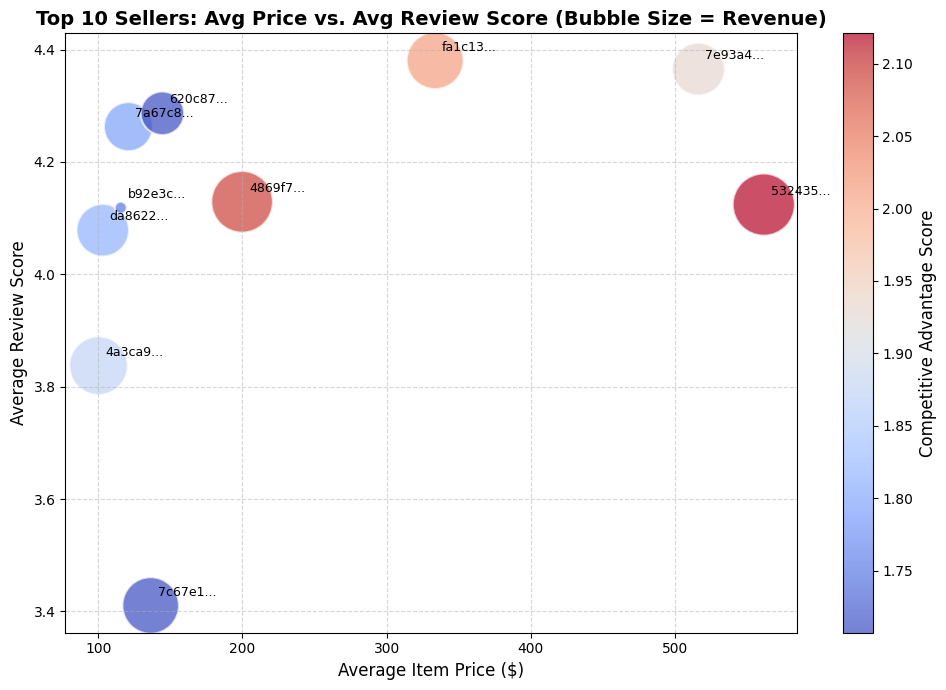

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. Calculate Delivery Delay in days (Actual - Estimated)
master_df['Delivery_Delay_Days'] = (master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)

# Filter for delivered orders with necessary data
score_df = master_df.dropna(subset=['price', 'review_score', 'Delivery_Delay_Days']).copy()

# 2. Group by seller_id
seller_summary = score_df.groupby('seller_id').agg(
    Total_Revenue=('price', 'sum'),
    Avg_Price=('price', 'mean'),
    Avg_Review_Score=('review_score', 'mean'),
    Avg_Delivery_Delay=('Delivery_Delay_Days', 'mean'),
    Total_Orders=('order_id', 'nunique')
).reset_index()

# Filter for sellers with at least 10 orders to reduce noise (1-order wonders)
seller_summary = seller_summary[seller_summary['Total_Orders'] >= 10].copy()

# 3. Normalize values using MinMaxScaler
scaler = MinMaxScaler()

# For Revenue and Review Score, higher is better
seller_summary[['Rev_Norm', 'Revw_Norm']] = scaler.fit_transform(seller_summary[['Total_Revenue', 'Avg_Review_Score']])

# For Delivery Delay, lower is better. We negate it before scaling so higher score = less delay
seller_summary['Delay_Neg'] = -seller_summary['Avg_Delivery_Delay']
seller_summary['Delay_Norm'] = scaler.fit_transform(seller_summary[['Delay_Neg']])

# Combine into a single score (max possible score is 3.0)
seller_summary['Competitive_Advantage_Score'] = seller_summary['Rev_Norm'] + seller_summary['Revw_Norm'] + seller_summary['Delay_Norm']

# 4. Identify the Top 10 Sellers
top_10_scoreboard = seller_summary.sort_values(by='Competitive_Advantage_Score', ascending=False).head(10)

print("--- Top 10 Sellers by Competitive Advantage Score ---")
print(top_10_scoreboard[['seller_id', 'Total_Revenue', 'Avg_Review_Score', 'Avg_Delivery_Delay', 'Competitive_Advantage_Score']])

# 5. Plot the Top 10 Sellers on a Scatter Plot
plt.figure(figsize=(10, 7))

# Bubble size scale factor 
bubble_sizes = (top_10_scoreboard['Total_Revenue'] / top_10_scoreboard['Total_Revenue'].max()) * 2000 

scatter = plt.scatter(
    x=top_10_scoreboard['Avg_Price'],
    y=top_10_scoreboard['Avg_Review_Score'],
    s=bubble_sizes,
    c=top_10_scoreboard['Competitive_Advantage_Score'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='w',
    linewidth=1.5
)

# Add a colorbar for the Score
cbar = plt.colorbar(scatter)
cbar.set_label('Competitive Advantage Score', fontsize=12)

# Add labels and title
plt.title('Top 10 Sellers: Avg Price vs. Avg Review Score (Bubble Size = Revenue)', fontsize=14, fontweight='bold')
plt.xlabel('Average Item Price ($)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add seller IDs as text next to the bubbles for reference
for i, row in top_10_scoreboard.iterrows():
    plt.annotate(
        row['seller_id'][:6] + '...',  # Show first 6 chars of seller_id to keep it clean
        (row['Avg_Price'], row['Avg_Review_Score']),
        fontsize=9,
        ha='left',
        va='bottom',
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()


### 8. Machine Learning Data Preparation
Preparing the data for a Random Forest model to predict `review_score`.
We'll create a feature matrix `X` and target vector `y`, fill any missing values with the median, and perform an 80/20 train-test split.

In [10]:
from sklearn.model_selection import train_test_split

# Define features to include
features = ['price', 'freight_value', 'product_description_lenght', 'product_photos_qty', 'Delivery_Speed_Days']

# Create the feature dataframe X and target variable y using master_df
X = master_df[features].copy()
y = master_df['review_score'].copy()

# Handle remaining NaN values in X by filling them with the median of each column
X = X.fillna(X.median())

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training Data Shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing Data Shape: X_test={X_test.shape}, y_test={y_test.shape}")


Training Data Shape: X_train=(94648, 5), y_train=(94648,)
Testing Data Shape: X_test=(23662, 5), y_test=(23662,)


### 9. Random Forest Model Training & Feature Importance
We'll train a `RandomForestRegressor` to predict `review_score`, evaluate it using Mean Absolute Error (MAE) and R-squared, and extract the feature importances to determine the biggest drivers of a high review score.

Model Performance on Test Set:
Mean Absolute Error (MAE): 0.8378
R-squared (R2) Score: 0.3306



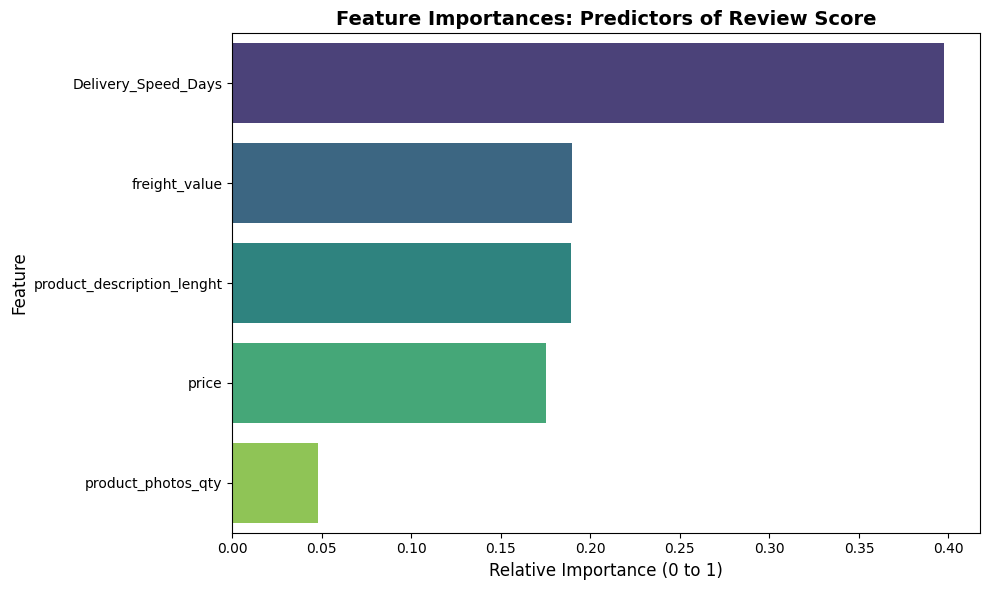


--- Competitive Advantage Summary ---
The most important factor influencing a customer's review score is 'Delivery_Speed_Days'.
For a seller, this signifies that optimizing this single operational aspect yields the highest return on customer satisfaction.
Cost-leadership (price and freight value) also play a role, but the data suggests that Differentiation (service and delivery execution) is what truly wins a 5-star review in the Olist marketplace.


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Predict on the test set and calculate MAE and R-squared
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}\n")

# 3. Extract Feature Importances
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances: Predictors of Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (0 to 1)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Print a brief summary
print("\n--- Competitive Advantage Summary ---")
top_feature = feature_imp_df.iloc[0]['Feature']
print(f"The most important factor influencing a customer's review score is '{top_feature}'.")
print("For a seller, this signifies that optimizing this single operational aspect yields the highest return on customer satisfaction.")
print("Cost-leadership (price and freight value) also play a role, but the data suggests that Differentiation (service and delivery execution) is what truly wins a 5-star review in the Olist marketplace.")


In [12]:
master_df.to_csv('final_olist_competitive_analysis.csv', index=False)

In [13]:
import joblib

# Save the trained RandomForestRegressor
joblib.dump(rf_model, 'rf_model.pkl')

# Save the X_train column names as a list in features.pkl
features_list = list(X_train.columns)
joblib.dump(features_list, 'features.pkl')

# Export a small, 5,000-row sample of master_df as streamlit_data.csv to ensure the app stays fast
# Note: Using master_df as it is the name used earlier in the notebook
master_df.sample(n=5000, random_state=42).to_csv('streamlit_data.csv', index=False)